# MMG4947 Midterm GDP Data Interpolation Project ;)

This project applies three curve fitting and data interpolation techniques to a real world economic dataset of U.S. quarterly GDP growth rates from 2010 to 2023. This data was pulled from the U.S. Bureau of Economic Analysis (BEA). The data represents the seasonally adjusted annual rate (SAAR) of real GDP growth in percent. The data includes the dramatic economic shock caused by the COVID-19 pandemic, this pandemic created drastic fluctuations in the data. Least squares linear regression was applied to determine whether a simple linear trend is a reasonable representation of GDP growth over time. Degree-4 poly fitting was applied to test whether a smooth curve could better capture the broader patterns in the data. Finally, cubic spline interpolation was used to evaluate whether exact interpolation through every data point is a reliable tool for estimating GDP growth between known quarters.

In [1]:
# importing thing needed!

import numpy as np
import matplotlib.pyplot as plt
import math

## Raw data set up!

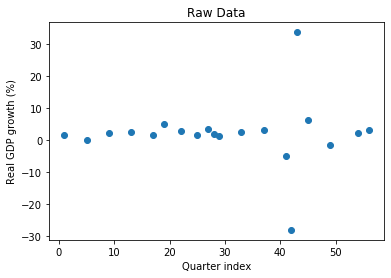

In [2]:
#convert the data into code and gragh the raw data
#calculating : year offset = (year - 2010) * 4, indexn numver = year offset + quarter number

x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

plt.scatter(x,y)
plt.xlabel("Quarter index")
plt.ylabel("Real GDP growth (%)")
plt.title("Raw Data")
plt.show()

#using this function for testing!
def findIndex(year, quarter):
    year_offset = (year - 2010) * 4
    return year_offset + quarter
    

## Part A — Cubic Spline Interpolation

In [3]:
#my own Cubic Spline methods

def thomas_algorithm(a, b, c, d): #from slides/slack 
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def getM(x, y, h, n): #from inclass challenge / slides formula
    
    a = np.zeros(n-2)
    b = np.zeros(n-2)
    c = np.zeros(n-2)
    d = np.zeros(n-2)
    
    #finding tri diag system
    for i in range(1, n - 1):
        a[i - 1] = h[i-1]
        b[i - 1] = 2* (h[i-1]+h[i])
        c[i - 1] = h[i] 
        d[i - 1] = 6*(((y[i+1]-y[i]) / h[i])-((y[i]-y[i-1]) / h[i-1]))
    m = thomas_algorithm(a,b,c,d) #solves the unkowns
    m = np.concatenate(([0], m, [0]))
    
    #print("m: ", m) #debug
    return m

    
def cubicSpline(x,y, unknownX):
    
    h = x[1:]-x[:-1] #getting the diff intervals
   # print("h:",h) #debug
    n = len(x)
  #  print("n:",n) #debug
    
    m = getM(x,y,h,n) #each sections function
    
    #find interval
    if(unknownX<x[0] or unknownX>x[-1]):
        print("Point out side of scope")
    else:
        
        i = np.searchsorted(x, unknownX) - 1 #had to google how to use this function
        i = np.clip(i,0,n-2) #had to google how to use this function
        #print("section:",i)#debug

        #plugging in!
        term1 = (m[i]/(6*h[i])) * (x[i+1] - unknownX)**3 
        term2 = m[i+1]/(6*h[i]) * (unknownX - x[i])**3
        term3 = (y[i]/h[i] - m[i]*h[i]/6) * (x[i+1]-unknownX)
        term4 = (y[i+1]/h[i] - m[i+1]*h[i]/6) * (unknownX - x[i])
        s = term1+term2+term3+term4
        
        return s
    
    
    
    

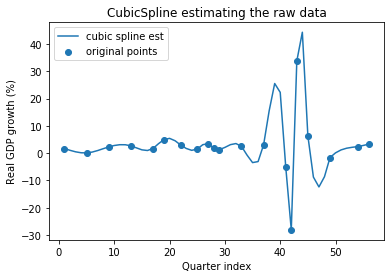

In [4]:
# implemet the cubic spline

#used claude ebcause i needed guidence on how to implement cubic spline in this case
#

x_unknowns = np.arange(1,57)
cs_est = np.zeros(len(x_unknowns))
for i in range(0,len(x_unknowns)):
    cs_est[i] = cubicSpline(x, y, x_unknowns[i])

plt.scatter(x,y,label="original points")
plt.plot(x_unknowns,cs_est, label ="cubic spline est")
plt.title("CubicSpline estimating the raw data")
plt.xlabel("Quarter index")
plt.ylabel("Real GDP growth (%)")
plt.legend()
plt.show()

1. Construct a natural cubic spline interpolant through the full dataset (all provided quarters). Clearly describe the system of equations you solve: how many unknowns are there, what are the continuity conditions at each interior knot, and what boundary conditions define a natural spline?
    - How many unknowns are there? The dataset has 20 known data points, so their 20 second derivative unknowns (M), one at each knot. Applying natural boundary conditions sets the first M to 0 and the last M to 0, reducing unknowns to 18, which are solved with the tridiagonal system and Thomas's algorithm.
    - What are the continuity conditions at each interior knot? At each interior knot, three continuity conditions are enforced:  the cubic pieces on either side has the same function value, their first derivatives match, and their second derivatives match. These conditions guarantee a smooth and seamless curve across the data. 
    - What boundary conditions define a natural spline? Natural splines cut off the end points of the known data, in this case we have no way of knowing what is happening before 2010 Q1 or after 2023 Q4. Mathmatically, the end points second derivatives are set to zero so their is no curve to use as an estimate beyond the data. 
2. The full quarterly dataset has 55 points (2010 Q1 through 2023 Q4). Using your spline from the subset above, evaluate it at every quarter in the full range and plot the result. Discuss whether the interpolant is visually smooth and reasonable.
    - The spline was evaluated at all 56 quarter indices spanning 2010 Q1 through 2023 Q4. For the majority of the range, the interpolant is visually smooth and tracks the general economic trend reasonably well. However, the curve becomes highly unstable in the region surrounding the COVID-19 pandemic quarters (indices 41–45), where the extreme values of −28.1% and +33.8% force sharp turns in the spline. Even though the math is correct, this behavior raises questions about whether exact interpolation is appropriate for data with such dramatic noise.
3. The spline must pass exactly through the 2020 Q2 value (−28.1%). Discuss the Runge phenomenon and the trade-off between exact interpolation and numerical stability for datasets with extreme outliers. Would smoothing splines or weighted least squares be preferable here? (No implementation required — discuss conceptually.)
    - The Runge phenomenon refers to the large oscillations that can appear when high degree global polynomials are forced to interpolate data exactly (overfitting data), especially near the ends of an interval. This dataset shows trade off between exact interpolation and realistic behavior. The 2020 Q2 value of -28.1% is an extreme outlier due to COVID-19, and forcing the spline to pass exactly through that point creates sharp changes in nearby intervals. This makes the interpolation mathematically correct but not always realistic.

## Part B — Polynomial & Least Squares Comparison

In [5]:

#my own least Squares Method
def leastsqr(x,y):
    #sumations
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x*x)
    sum_xy = np.sum(x*y)
    
    #calculate
    n = np.size(x)
    m = (n* sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    c = (sum_y - m*sum_x)/n
    
    return m,c



In [6]:
#my own Poly-fit Method

def polyFit(x,y,degree):
    #step 1 - create vandermonde matrix
    V = np.vander(x, N=degree+1, increasing=True)
    #step 2 - solve for coeffeincts
    VT_V =np.dot(V.T,V)
    VT_y = np.dot(V.T,y)
    
    coefficents = np.linalg.solve(VT_V, VT_y)
    polynomial = np.poly1d(coefficents[::-1])
    
    return polynomial
    
    

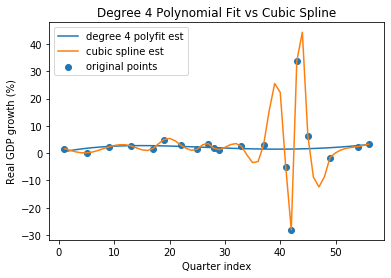

slope: -0.001906988188976378


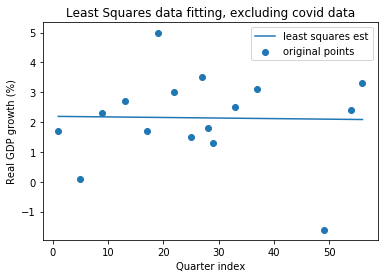

In [7]:
# implement the poly fit and least squares
poly = polyFit(x,y,4)
poly_est = poly(np.arange(1,57))

plt.scatter(x,y,label="original points")
plt.plot(np.arange(1,57),poly_est, label ="degree 4 polyfit est")
plt.plot(x_unknowns,cs_est, label ="cubic spline est")
plt.title("Degree 4 Polynomial Fit vs Cubic Spline")

plt.xlabel("Quarter index")
plt.ylabel("Real GDP growth (%)")
plt.legend()
plt.show()


x_filtered = np.delete(x, [13, 14, 15, 16])
y_filtered = np.delete(y, [13, 14, 15, 16])

m,c = leastsqr(x_filtered,y_filtered)
print("slope:",m)
ls_est = m*x_filtered + c

plt.scatter(x_filtered,y_filtered,label="original points")
plt.plot(x_filtered,ls_est, label ="least squares est")
plt.title("Least Squares data fitting, excluding covid data")
plt.xlabel("Quarter index")
plt.ylabel("Real GDP growth (%)")
plt.legend()
plt.show()





1. Fit a degree-4 polynomial to the data using least squares (this does not need to pass through every point). Plot it alongside the cubic spline. Which model better captures the overall trend, and which better reproduces specific data points? Discuss the trade-off between approximation and interpolation.
    - The degree 4 polynomial approximates the overall shape of the GDP data without passing through every point, effectively smoothing over noisy quarters. In contrast, the cubic spline enforces exact interpolation at every knot, meaning it faithfully reproduces each data point but with that it inherits all noise present in the data, this is most evident in the COVID-19 years. This illustrates the trade-off between approximation and interpolation: the polynomial is better for capturing the broad economic trend, while the spline is better when exact reproduction of specific quarterly values is required.
2. Fit a least squares linear model to the data excluding the COVID quarters (2020 Q1–2021 Q1). Report the slope. Does a linear trend make economic sense for this data? What assumptions does it require?
    - Excluding the COVID quarters, the least squares linear model produces a slope of −0.0019% GDP growth per quarter. This near zero slope suggests that GDP growth was essentially flat over the 2010–2023 period after pandemic data is removed, which is economically reasonable. Mature economies, like the US, tend to be stable, modest growth or decay rather than large increase or decline. However, a linear model has some assumptions: it treats GDP growth as changing value at a constant rate over time, ignores economic cycle patterns, and assumes the relationship between time and growth is simple with no random nuances.

## Part C — Method Justification

Poly RMSE: 10.031440678677114
Poly R2: 0.00354101511853977

LS RMSE: 1.4431864883291987
LS R2: 0.00044329440682566723


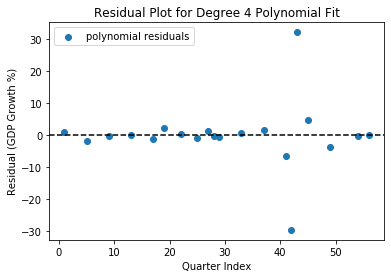

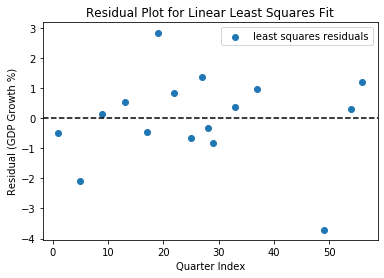

In [8]:
# finding quantitiative support for the two methods

# RMSE and R-squared for poly fit - the scores for cubic spline would be 0 becuase it is forced to hit every point!
poly_est = poly(x)
residuals_poly = y - poly_est
RMSE_poly = np.sqrt(np.mean(residuals_poly**2))

ss_res = np.sum(residuals_poly**2)
ss_tot = np.sum((y - np.mean(y))**2)
R2_poly = 1 - (ss_res/ss_tot)

print("Poly RMSE:", RMSE_poly)
print("Poly R2:", R2_poly)

print()
# RMSE and R-squared for least squares (on filtered data)
ls_est = m*x_filtered + c
residuals_ls = y_filtered - ls_est
RMSE_ls = np.sqrt(np.mean(residuals_ls**2))

ss_res_ls = np.sum(residuals_ls**2)
ss_tot_ls = np.sum((y_filtered - np.mean(y_filtered))**2)
R2_ls = 1 - (ss_res_ls/ss_tot_ls)

print("LS RMSE:", RMSE_ls)
print("LS R2:", R2_ls)

# residual plot for poly fit
plt.scatter(x, residuals_poly, label="polynomial residuals")
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot for Degree 4 Polynomial Fit")
plt.xlabel("Quarter Index")
plt.ylabel("Residual (GDP Growth %)")
plt.legend()
plt.show()


# residual plot for linear least squares fit (on filtered data)
ls_at_data = m * x_filtered + c
ls_residuals = y_filtered - ls_at_data

plt.scatter(x_filtered, ls_residuals, label="least squares residuals")
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot for Linear Least Squares Fit")
plt.xlabel("Quarter Index")
plt.ylabel("Residual (GDP Growth %)")
plt.legend()
plt.show()

## Qualitative data

##### value meaning
Root Mean Squared error meaning:
- Measures the average error between predicted and actual values, in the same units as your data (GDP %)
- Lower = better fit
- RMSE of 2.0 means the model is off by about 2% 

r-squared meaning:
- Measures how much of the variance in the data your model explains
- closer to 1 = better fit
- a R^2 of 0.85 means the model explains 85% of the variation

Big O meaning:
- Big O helps determine if an algorithm will scale. A O(1) will always be the same time complexity but an O(n^2) might work for 100 items but become too slow for 1,000,000 items

##### each method
Cubic Spline:
- The cubic spline hits every point exactly, so RMSE adn R^2 is 0 and r^2 is 1. This is actually the problem — perfect fit on known points doesn't mean good behavior inbetween each point
- Big O -> O(n) to solve the tridiagonal system with Thomas Algorithm 

Poly Fit:
- based on the RMSE and R^2, the polyfit is off by about 10% GDP on average, and explains basically 0% of the variance. This value however makes since because it is ignoring the noise from the COVID data and the data is so scattered that a straight line can't really explain the variance.
- Big O -> for a degree 4, O(n*d^2) - building and solving a vandermonde matrix


least squares:
- based on the RMSE and R^2, the least squares is off by about 1.4% GDP on average, and explains basically 0% of the variance. This value however makes since because it is using filtered data. 
- Big O -> O(n) - just summations

1. For a policymaker who needs to estimate GDP growth for a quarter between two known data points (interpolation), which method would you recommend: cubic spline or polynomial fitting? Justify your answer with reference to smoothness, accuracy, and sensitivity to outliers.
     - For a policymaker estimating GDP growth for a quarter between two known data points, I would recommend the cubic spline method. Since the task is interpolation, the spline is the most appropriate because it is specifically built to estimate values between known data while still passing exactly through every recorded GDP point.
     - The cubic spline is smooth because each interval is connected so that the function, first derivative, and second derivative match at each point. This gives a more natural quarter to quarter transition than a single polynomial, which tries to use one equation to represent the entire dataset.
     - In terms of accuracy, the cubic spline reproduces the known data points exactly, so it is the strongest method when the goal is to estimate between nearby known quarters rather than capture one broad overall trend. The degree 4 polynomial is better for showing the general shape of GDP growth over time, but the datas a whole is affected by noise while the spline is only effcted around the noisy points.
     - The main limitation of the cubic spline is its sensitivity to extreme outliers. In this dataset, the COVID quarters force sharp changes in the curve, especially near 2020 Q2 and 2020 Q3. This means the spline should be interpreted carefully in that region, because exact interpolation through unusual economic shocks can create estimates that make mathematical sense but are not realistic. Even with this limitation, the spline is still the better recommendation for interpolation because it is designed for estimating values between known points, while the polynomial fit is more useful for trend analysis.

2. After doing Big O analysis, does the recommendation change? why?
     - After considering computational cost, my recommendation does not change. The cubic spline remains the best choice for interpolation. Using Thomas's algorithm the spline solves a tridiagonal system in O(n) time, which is efficient and scales well for this size dataset.
     - The least squares linear model is also O(n), but it is too simple to capture the trends of the data. The degree 4 polynomial fit is more expensive because building and solving the Vandermonde based system is about O(n*d^2), although with a degree 4 fit, this is still a reasonably time complexity. 
     - Because all three methods are computationally reasonable for only 20 data points, Big O does not change the practical recommendation. The deciding factor is not speed in this case but which method best matches the purpose of the problem.

# Conclusion 

Across all three methods, no single approach proved universally superior and each performed best for a different purpose. The cubic spline was the most effective tool for exact interpolation, reproducing every known data point precisely by fitting a unique cubic polynomial to each interval with each line segment matching original curve, first derivative and second derivative values to ensure smoothness. This is why cubic spline was the best method for interpolation between known quarters. However, its major limitation is its sensitivity to noisy data, passing exactly through every outlier like the COVID-19 quarters caused wild behavior in neighboring line segments. This means a zero RMSE value at known points does not guarantee reliable estimates between them. The degree 4 polynomial was the best method for visualizing the overall economic trend, producing a smooth and interpretable curve across the full data range. Its main limitation is that extreme outliers in the dataset influenced the entire trend line resulting in a high RMSE and an R^2 near zero. Least squares linear regression was the simplest and most computationally efficient method, but it over-generalizes complex economic data into a single straight line, failing to capture the variation in quarter to quarter GDP growth. This project highlighted a fundamental trade off in numerical methods: interpolation prioritizes accuracy at known points while approximation prioritizes behavior across the full range. 


## Ai use citations!

For this whole project I used Claude ai when I was stuck or needed quick guidance 

prompt: what is the best way to organize the years/GDP raw data? (attached the project instructions)
- why: I wasn't sure how to represnt the data in a way that made sense to other people reading the code and wouldnt complicate calculations.

prompt: can you point out what i am doing wrong (attached my current progress in a .py file and the project instructions)
- why: I did this twice, once becuase i was getting runtime errors while testing my cubic spline and once because i had errors i didnt understand trying to apply the least squares method to the filtered data.

prompt: how do i interpret R-squared and RMSE results together for a poly fit and least squares interpolation?
- why: I wasn't sure how these quantitaive evidence should be used and what the values actully meant. 

prompt: am i missing anything from the instructions? do all my methods work as intended? do all of my explainations make sense and are they gramatically correct? (attached my finished but unpolished proeject .py file and the project instructions)
- why: I wanted to make sure i was hitting all the important parts and didn't make a mindless mistake. 


prompt: how do i gragh the residuals in a way that is easy for anyone to understand? ( a follow up to the above questione
- why: The responce to polishing question was that i was missing the gragh of the residual errors, but i didnt fully understand what this meant so i wanted to find a simple way to represnt the error.